# Online Retail ii uci Dataset

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler, LabelEncoder
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/online-retail-ii-uci/online_retail_II.csv


## 2. Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/online-retail-ii-uci/online_retail_II.csv", encoding='latin1')
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [4]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

In [5]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [6]:
df.duplicated().sum()

34335

## 3. Handle Missing Values

In [7]:
df = df.dropna(subset=["Customer ID"])
df = df.drop_duplicates()

## 4. Remove Outliers (Quantity, Price)

In [8]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df = remove_outliers_iqr(df, "Quantity")
df = remove_outliers_iqr(df, "Price")

## 5. Feature Engineering

In [9]:
df["TotalPrice"] = df["Quantity"] * df["Price"]
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["InvoiceYear"] = df["InvoiceDate"].dt.year
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df["InvoiceDay"] = df["InvoiceDate"].dt.day
df["InvoiceHour"] = df["InvoiceDate"].dt.hour
df = df.drop("InvoiceDate", axis=1)

## 6. Encoding Categorical Variables

In [10]:
if "Country" in df.columns:
    le = LabelEncoder()
    df["Country_Encoded"] = le.fit_transform(df["Country"].astype(str))

df = df.drop([col for col in ["Description", "StockCode", "Country"] if col in df.columns], axis=1)

if "Customer ID" in df.columns:
    df["Customer ID"] = df["Customer ID"].astype(str)

## 7. Create RFM Dataset

In [11]:
rfm = df.groupby("Customer ID").agg({
    "TotalPrice": "sum",
    "Quantity": "sum"
}).reset_index()

rfm["Frequency"] = df.groupby("Customer ID").size().values
rfm.columns = ["Customer ID", "Monetary", "Quantity", "Frequency"]
rfm = rfm[["Customer ID", "Frequency", "Monetary", "Quantity"]]

## 8. Scaling with RobustScaler

In [12]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
scaler = RobustScaler()
scaled_data = scaler.fit_transform(df[numeric_cols])

## 9. Elbow Method

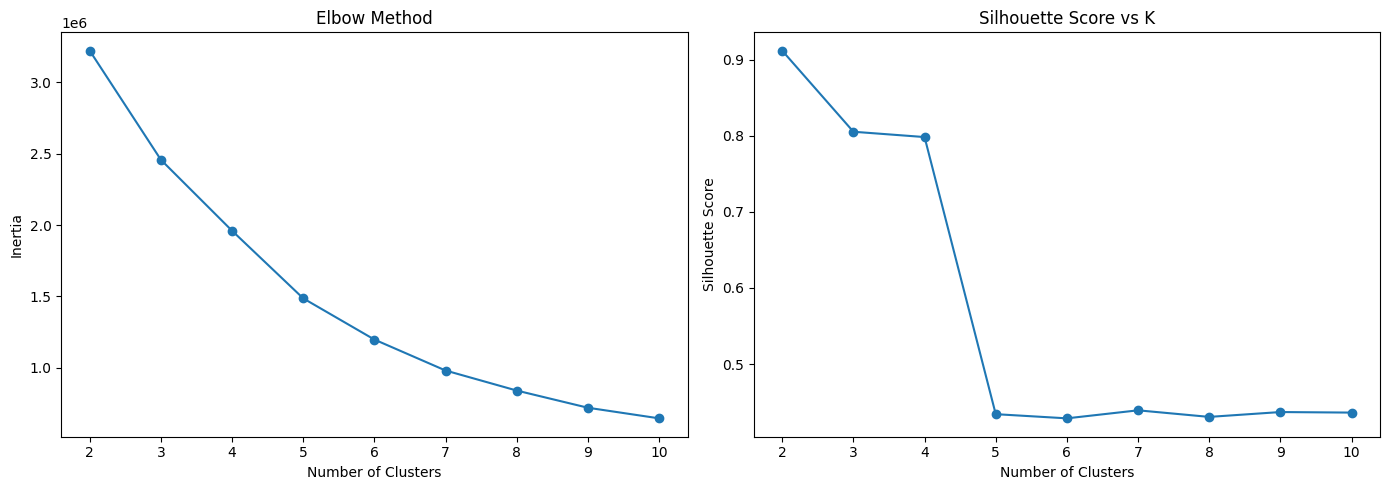

In [13]:
inertia = []
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_, sample_size=10000, random_state=42))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(range(2, 11), inertia, marker='o')
ax[0].set_xlabel("Number of Clusters")
ax[0].set_ylabel("Inertia")
ax[0].set_title("Elbow Method")

ax[1].plot(range(2, 11), silhouette_scores, marker='o')
ax[1].set_xlabel("Number of Clusters")
ax[1].set_ylabel("Silhouette Score")
ax[1].set_title("Silhouette Score vs K")
plt.tight_layout()
plt.show()

## 10. K-Means Clustering

In [14]:
k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42)
kmeans_labels = kmeans.fit_predict(scaled_data)
df["KMeans_Cluster"] = kmeans_labels

kmeans_silhouette = silhouette_score(scaled_data, kmeans_labels, sample_size=10000, random_state=42)
kmeans_davies = davies_bouldin_score(scaled_data, kmeans_labels)

print("K-Means Results:")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Davies-Bouldin Score: {kmeans_davies:.4f}")

pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_data)
pca_df = pd.DataFrame(pca_components, columns=['PCA1', 'PCA2'])
pca_df['KMeans_Cluster'] = kmeans_labels

K-Means Results:
Silhouette Score: 0.7985
Davies-Bouldin Score: 0.5097


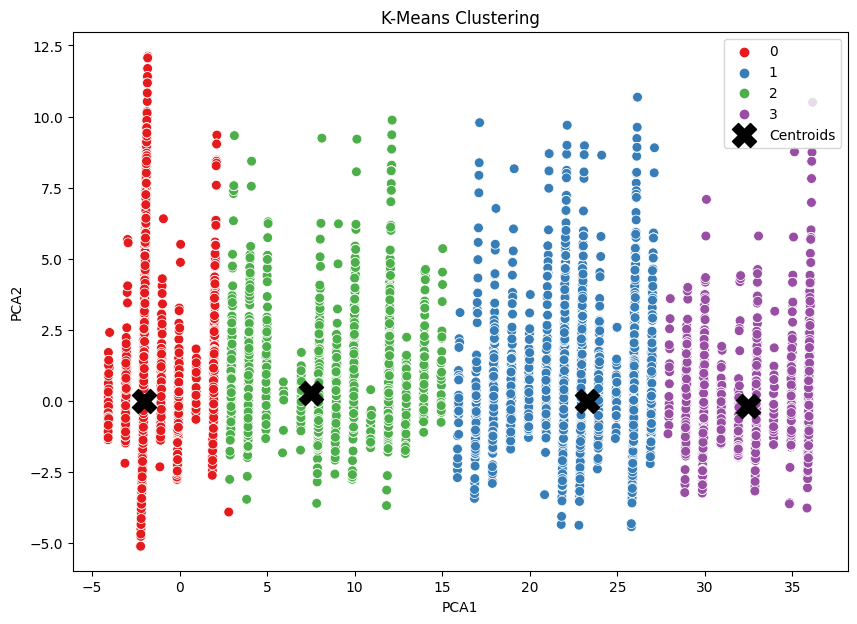

In [15]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='KMeans_Cluster', palette='Set1', s=50)
centroids = kmeans.cluster_centers_
pca_centroids = pca.transform(centroids)
plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1], s=300, c='black', marker='X', label='Centroids')
plt.title('K-Means Clustering')
plt.legend()
plt.show()

## 11. DBSCAN Clustering

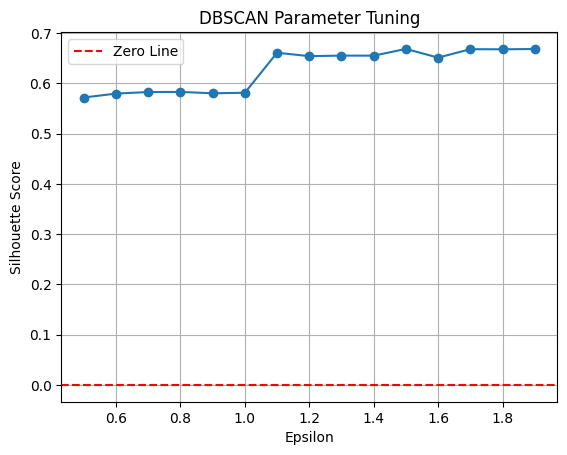

In [16]:
scaled_data_df = pd.DataFrame(scaled_data)
sample = scaled_data_df.sample(n=20000, random_state=42)

db_scores = []
eps_values = np.arange(0.5, 2.0, 0.1)

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=10)
    labels = dbscan.fit_predict(sample)
    unique_labels = set(labels) - {-1}
    if len(unique_labels) > 1:
        non_noise = labels != -1
        if sum(non_noise) > 0:
            db_scores.append(silhouette_score(sample[non_noise], labels[non_noise]))
        else:
            db_scores.append(-1)
    else:
        db_scores.append(-1)

plt.plot(eps_values, db_scores, marker='o')
plt.xlabel("Epsilon")
plt.ylabel("Silhouette Score")
plt.title("DBSCAN Parameter Tuning")
plt.axhline(y=0, color='r', linestyle='--', label='Zero Line')
plt.legend()
plt.grid(True)
plt.show()

Best epsilon: 1.50 with Silhouette: 0.6686

DBSCAN Results:
Silhouette Score: 0.6686
Davies-Bouldin Score: 0.5308


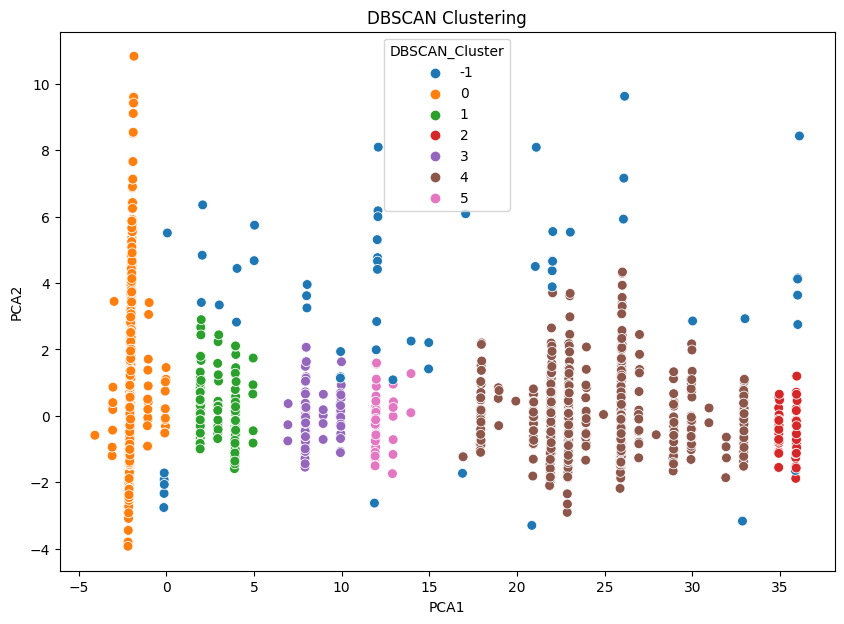

In [17]:
best_eps_idx = np.argmax(db_scores)
best_eps = eps_values[best_eps_idx]
print(f"Best epsilon: {best_eps:.2f} with Silhouette: {db_scores[best_eps_idx]:.4f}")

dbscan = DBSCAN(eps=best_eps, min_samples=10)
dbscan_labels = dbscan.fit_predict(sample)

pca_sample = pca.transform(sample)
pca_df_dbscan = pd.DataFrame(pca_sample, columns=['PCA1', 'PCA2'])
pca_df_dbscan['DBSCAN_Cluster'] = dbscan_labels

if len(set(dbscan_labels)) > 2:
    dbscan_silhouette = silhouette_score(sample[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    dbscan_davies = davies_bouldin_score(sample[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
    print("\nDBSCAN Results:")
    print(f"Silhouette Score: {dbscan_silhouette:.4f}")
    print(f"Davies-Bouldin Score: {dbscan_davies:.4f}")

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df_dbscan, x='PCA1', y='PCA2', hue='DBSCAN_Cluster', palette='tab10', s=50)
plt.title('DBSCAN Clustering')
plt.show()

## 12. Model Comparison

In [19]:
results = pd.DataFrame({
    'Model': ['K-Means', 'DBSCAN'],
    'Silhouette Score': [kmeans_silhouette, dbscan_silhouette if len(set(dbscan_labels)) > 2 else 0],
    'Davies-Bouldin Score': [kmeans_davies, dbscan_davies if len(set(dbscan_labels)) > 2 else 0]
})

print("\nModel Comparison:")
print(results)


Model Comparison:
     Model  Silhouette Score  Davies-Bouldin Score
0  K-Means          0.798474              0.509725
1   DBSCAN          0.668559              0.530753
